# Exploratory Analysis: Smart TV Consumer Market

## Research Question

**What product attributes drive consumer satisfaction in the smart TV market,
and how is Samsung positioned relative to major competitors?**

This notebook explores the structure of the analytical dataset before
examining consumer review text. The analysis focuses on Samsung, LG, Sony,
TCL, and Hisense and examines market composition, review activity, customer
ratings, and differences across brands.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [2]:
products = pd.read_parquet(
    "tv_products_clean.parquet"
)

reviews = pd.read_parquet(
    "tv_reviews_clean.parquet"
)

print("Products:", products.shape)
print("Reviews:", reviews.shape)

Products: (1097, 17)
Reviews: (111191, 14)


In [3]:
print("Product columns:")
print(products.columns.tolist())

print("\nReview columns:")
print(reviews.columns.tolist())

Product columns:
['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'store', 'categories', 'details', 'parent_asin', 'brand', 'price_numeric', 'is_smart_tv', 'year', 'strong_smart_signal', 'is_bundle']

Review columns:
['rating', 'title', 'text', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'brand', 'review_date', 'review_year', 'text_clean', 'text_length']


In [4]:
product_counts = (
    products["brand"]
    .value_counts()
    .rename("products")
)

In [5]:
review_counts = (
    reviews["brand"]
    .value_counts()
    .rename("reviews")
)

In [6]:
avg_ratings = (
    reviews
    .groupby("brand")["rating"]
    .mean()
    .rename("avg_rating")
)

In [7]:
brand_overview = pd.concat(
    [
        product_counts,
        review_counts,
        avg_ratings
    ],
    axis=1
)

brand_overview["reviews_per_product"] = (
    brand_overview["reviews"]
    / brand_overview["products"]
)

brand_overview = (
    brand_overview
    .sort_values(
        "reviews",
        ascending=False
    )
)

display(
    brand_overview.round(2)
)

,products,reviews,avg_rating,reviews_per_product
brand,,,,
TCL,94,41559,3.86,442.12
Samsung,399,32662,3.87,81.86
LG,308,15108,4.03,49.05
Sony,204,12209,3.97,59.85
Hisense,92,9653,3.59,104.92


In [82]:
import os

FIGURE_DIR = "outputs/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

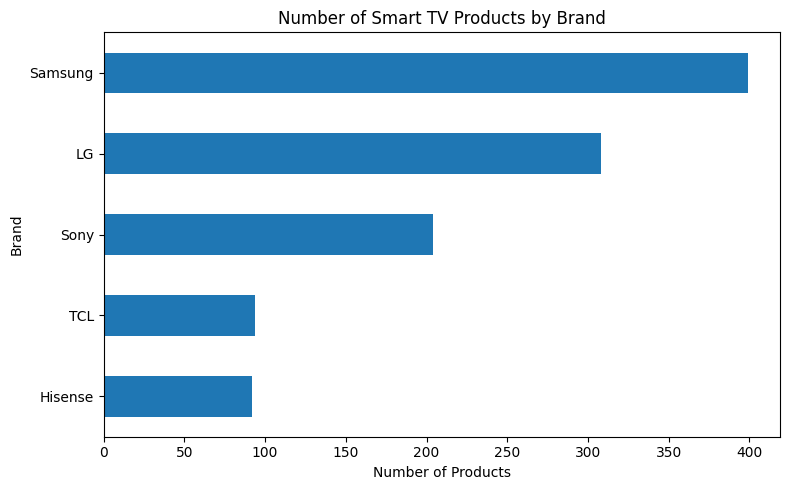

In [84]:
product_plot = (
    products["brand"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

product_plot.plot(
    kind="barh"
)

plt.title(
    "Number of Smart TV Products by Brand"
)

plt.xlabel(
    "Number of Products"
)

plt.ylabel(
    "Brand"
)

# Number of Smart TV Products by Brand
plt.savefig(
    f"{FIGURE_DIR}/03_products_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

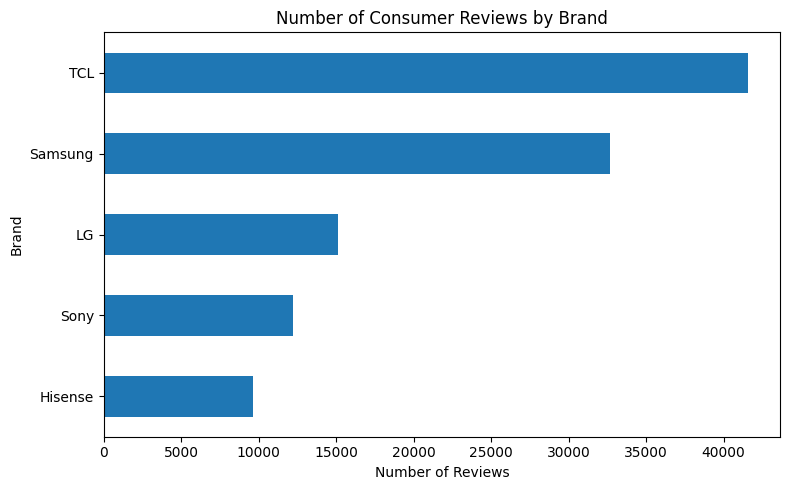

In [85]:
review_plot = (
    reviews["brand"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

review_plot.plot(
    kind="barh"
)

plt.title(
    "Number of Consumer Reviews by Brand"
)

plt.xlabel(
    "Number of Reviews"
)

plt.ylabel(
    "Brand"
)

# Number of Consumer Reviews by Brand
plt.savefig(
    f"{FIGURE_DIR}/03_reviews_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [10]:
rating_distribution = (
    reviews["rating"]
    .value_counts()
    .sort_index()
)

rating_percent = (
    reviews["rating"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

rating_summary = pd.DataFrame({
    "reviews": rating_distribution,
    "percent": rating_percent
})

display(
    rating_summary.round(2)
)

,reviews,percent
rating,,
1.0,19409,17.46
2.0,6553,5.89
3.0,7354,6.61
4.0,13077,11.76
5.0,64798,58.28


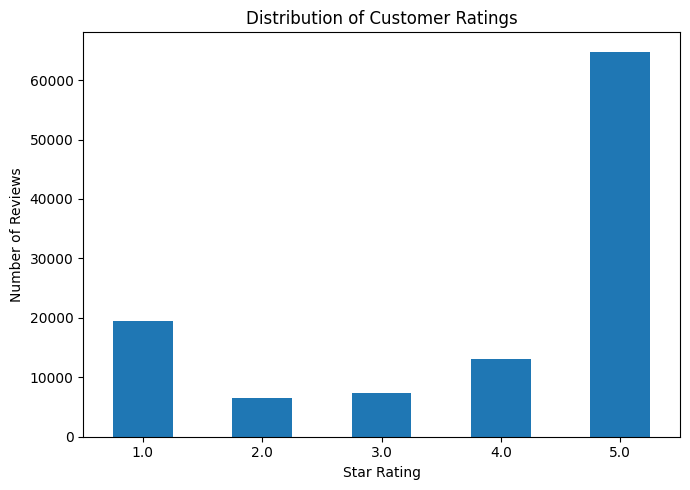

In [86]:
plt.figure(figsize=(7, 5))

rating_distribution.plot(
    kind="bar"
)

plt.title(
    "Distribution of Customer Ratings"
)

plt.xlabel(
    "Star Rating"
)

plt.ylabel(
    "Number of Reviews"
)

plt.xticks(rotation=0)

# Overall Customer Rating Distribution
plt.savefig(
    f"{FIGURE_DIR}/03_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


In [12]:
brand_rating_dist = pd.crosstab(
    reviews["brand"],
    reviews["rating"],
    normalize="index"
) * 100

display(
    brand_rating_dist.round(2)
)

rating,1.0,2.0,3.0,4.0,5.0
brand,,,,,
Hisense,23.12,7.20,7.29,12.01,50.38
LG,13.93,5.18,6.59,12.90,61.40
Samsung,17.68,6.03,6.80,10.81,58.68
Sony,15.49,5.57,6.74,11.06,61.14
TCL,17.82,5.84,6.28,12.24,57.82


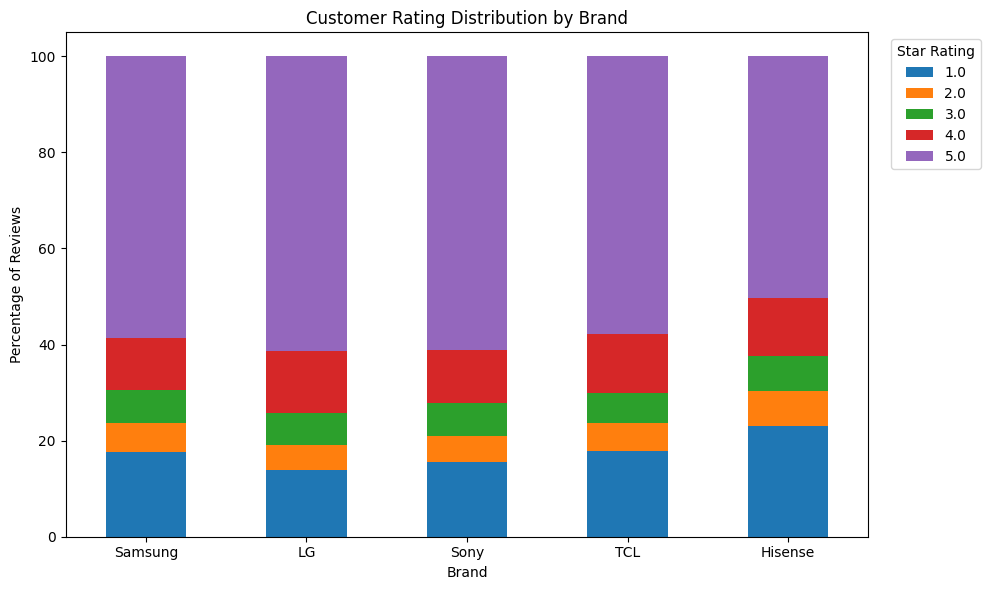

In [87]:
brand_order = [
    "Samsung",
    "LG",
    "Sony",
    "TCL",
    "Hisense"
]

brand_rating_dist.loc[
    brand_order
].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title(
    "Customer Rating Distribution by Brand"
)

plt.xlabel(
    "Brand"
)

plt.ylabel(
    "Percentage of Reviews"
)

plt.xticks(rotation=0)

plt.legend(
    title="Star Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Customer Rating Distribution by Brand
plt.savefig(
    f"{FIGURE_DIR}/03_rating_distribution_by_brand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [14]:
review_weighted_rating = (
    reviews
    .groupby("brand")["rating"]
    .mean()
    .rename("review_weighted_rating")
)

In [15]:
product_ratings = (
    reviews
    .groupby(
        ["brand", "parent_asin"]
    )["rating"]
    .mean()
    .reset_index(
        name="product_avg_rating"
    )
)

display(
    product_ratings.head()
)

,brand,parent_asin,product_avg_rating
0,Hisense,B00U0GZR34,3.627451
1,Hisense,B00XMUU4QK,4.013514
2,Hisense,B00ZGIJBXS,4.142857
3,Hisense,B00ZGIJDOU,4.333333
4,Hisense,B00ZGIJE9E,4.126214


In [16]:
product_weighted_rating = (
    product_ratings
    .groupby("brand")[
        "product_avg_rating"
    ]
    .mean()
    .rename(
        "product_weighted_rating"
    )
)

In [17]:
rating_comparison = pd.concat(
    [
        review_weighted_rating,
        product_weighted_rating
    ],
    axis=1
)

rating_comparison["difference"] = (
    rating_comparison[
        "review_weighted_rating"
    ]
    -
    rating_comparison[
        "product_weighted_rating"
    ]
)

display(
    rating_comparison.round(3)
)

,review_weighted_rating,product_weighted_rating,difference
brand,,,
Hisense,3.593,3.637,-0.043
LG,4.027,4.097,-0.070
Samsung,3.868,3.972,-0.104
Sony,3.968,4.157,-0.189
TCL,3.864,3.893,-0.029


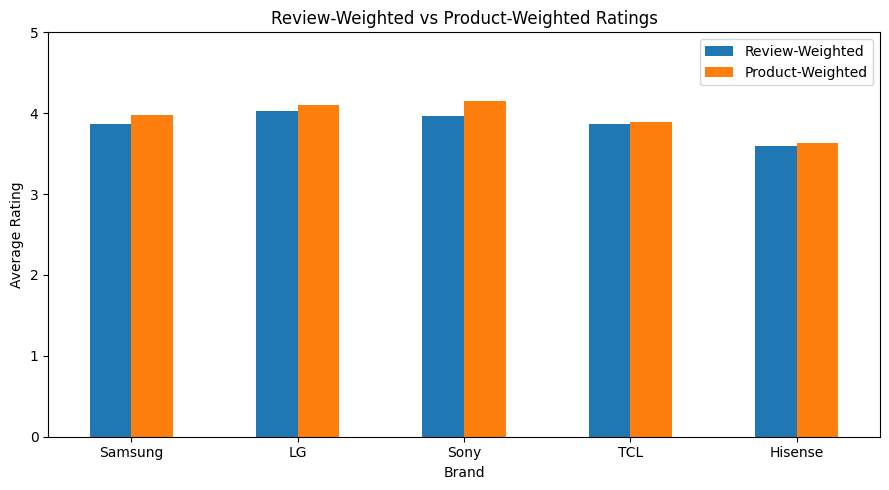

In [88]:
rating_comparison[
    [
        "review_weighted_rating",
        "product_weighted_rating"
    ]
].loc[
    brand_order
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Review-Weighted vs Product-Weighted Ratings"
)

plt.xlabel(
    "Brand"
)

plt.ylabel(
    "Average Rating"
)

plt.ylim(0, 5)

plt.xticks(rotation=0)

plt.legend(
    [
        "Review-Weighted",
        "Product-Weighted"
    ]
)

# Review-Weighted vs Product-Weighted Ratings
plt.savefig(
    f"{FIGURE_DIR}/03_weighted_rating_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

In [19]:
reviews_per_product = (
    reviews
    .groupby(
        ["brand", "parent_asin"]
    )
    .size()
    .reset_index(name="review_count")
)

In [20]:
reviews_per_product["brand_total_reviews"] = (
    reviews_per_product
    .groupby("brand")["review_count"]
    .transform("sum")
)

reviews_per_product["review_share"] = (
    reviews_per_product["review_count"]
    / reviews_per_product["brand_total_reviews"]
)

In [21]:
def concentration_summary(group):
    counts = (
        group["review_count"]
        .sort_values(ascending=False)
    )

    total = counts.sum()

    return pd.Series({
        "top_1_share": counts.iloc[:1].sum() / total * 100,
        "top_5_share": counts.iloc[:5].sum() / total * 100,
        "top_10_share": counts.iloc[:10].sum() / total * 100
    })


brand_concentration = (
    reviews_per_product
    .groupby("brand")
    .apply(
        concentration_summary,
        include_groups=False
    )
)

display(
    brand_concentration.round(2)
)

,top_1_share,top_5_share,top_10_share
brand,,,
Hisense,6.58,28.87,49.92
LG,8.06,26.93,41.57
Samsung,11.21,37.14,49.81
Sony,7.42,26.39,42.71
TCL,15.08,67.71,83.80


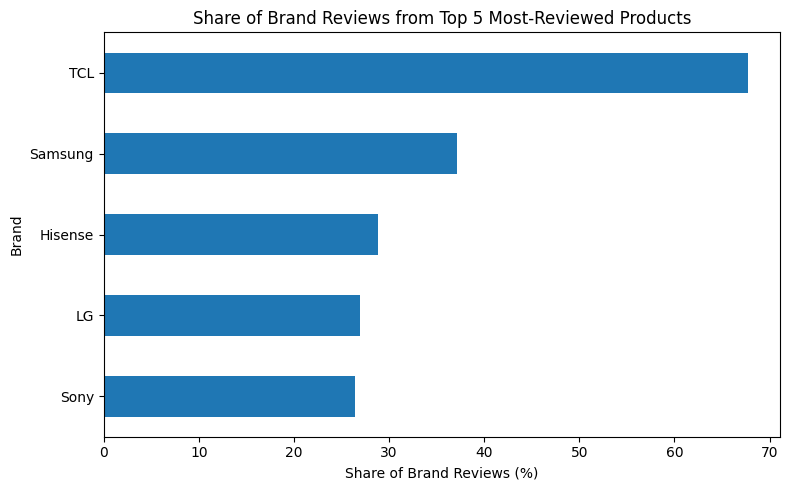

In [89]:
top5_plot = (
    brand_concentration["top_5_share"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))

top5_plot.plot(
    kind="barh"
)

plt.title(
    "Share of Brand Reviews from Top 5 Most-Reviewed Products"
)

plt.xlabel(
    "Share of Brand Reviews (%)"
)

plt.ylabel(
    "Brand"
)

# Review Concentration
plt.savefig(
    f"{FIGURE_DIR}/03_review_concentration_top5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


In [26]:
sample_titles = (
    products
    .groupby("brand")
    .sample(
        n=15,
        random_state=42
    )
)

display(
    sample_titles[
        [
            "brand",
            "title",
            "year"
        ]
    ]
)

,brand,title,year
418,Hisense,"Hisense ULED Premium 55U7G QLED Series 55-inch Android 4K Smart TV with Alexa Compatibility, 1000-nit HDR10+, Dolby Vision & Atmos, 120Hz, HDMI 2....",2021.0
212,Hisense,"Hisense ULED 4K Premium 50U6G1 Quantum Dot QLED Series 50-Inch Smart Google TV, Dolby Vision Atmos, Voice Remote, Compatible with Alexa (2022 Model)",2022.0
664,Hisense,"Hisense 85-Inch 4K Ultra HD Android Smart TV with Alexa Compatibility (85H6570G, 2020 Model)",2020.0
820,Hisense,"Hisense 4K UHD A7H Series 85-Inch Class Smart Google TV with Voice Remote (85A7H, 2022 Model) ,Black",2022.0
10,Hisense,"Hisense 43-Inch Class H4 Series LED Roku Smart TV with Google Assistant and Alexa Compatibility (43H4G, 2021 Model)",2021.0
...,...,...,...
1015,TCL,TCL 50S446 50 inch Class 4-Series 4K UHD HDR Smart Google TV Bundle with 2 YR CPS Enhanced Protection Pack,2023.0
875,TCL,"TCL 55S423 55"" Class (54.6"" Diag) 4K UHD Roku LED LCD",2019.0
102,TCL,"TCL 65-inch Class 4-Series 4K UHD HDR Smart Roku TV – 65S435, 2021 Model Alto R1 Roku TV Wireless 2.0 Channel Sound Bar",2021.0
945,TCL,"TCL 65-inch Class 6-Series 8K Mini-LED UHD QLED Dolby Vision HDR Smart Roku TV - 65R648, 2021 model",2021.0


In [27]:
display(
    products[
        [
            "title",
            "features",
            "details"
        ]
    ].sample(
        5,
        random_state=42
    )
)

,title,features,details
44,"LG OLED C1 Series 55"" Alexa Built-in 4k Smart TV, 120Hz Refresh Rate, AI-Powered, Dolby Vision IQ and Dolby Atmos, WiSA Ready, Gaming Mode (OLED5...",[OLED DISPLAY: Watch your content come to life in over 8 million pixels. Each pixel turns on and off independently so you'll see your content with...,"{""Brand Name"": ""LG"", ""Item Weight"": ""50 pounds"", ""Product Dimensions"": ""9.9\""D x 48.3\""W x 29.1\""H"", ""Item model number"": ""OLED55C1PUB"", ""Is Disco..."
568,Samsung UN65KS9800 Curved 65-Inch 4K Ultra HD Smart LED TV (2016 Model),[The Ultimate Curved 4K SUHD Picture powered by the Quantum Dot Color Drive. Fires off a billion more colors than HD TVs for a lifelike picture un...,"{""Brand Name"": ""SAMSUNG"", ""Item Weight"": ""67.5 Pounds"", ""Product Dimensions"": ""56.8 x 14.5 x 35.9 inches"", ""Item model number"": ""UN65KS9800FXZA"", ..."
56,"LG 80 Series 43” Alexa Built-in, 4K UHD Smart TV, Native 60Hz Refresh Rate, Dolby Cinema, Director Settings, Gaming Mode, with Magic Remote (43UP8...","[REAL 4K DISPLAY: The rich 4K displays of LG UHD TVs deliver quality you can see in every scene. Enjoy bright colors, high contrast, and impeccabl...","{""Brand Name"": ""LG"", ""Item Weight"": ""19.2 pounds"", ""Product Dimensions"": ""8.5\""D x 38.07\""W x 24.48\""H"", ""Item model number"": ""43UP8000PUA"", ""Spec..."
636,"SAMSUNG QN43Q6DAAFXZA 43"" 4K QLED Quantum HDR Smart TV with an Additional 2 Year Coverage by Epic Protect (2021)","[100% Color Volume with Quantum Dot: Get a billion brilliant colors that stay true even in bright scenes, Dual LED: Embrace every bold detail deli...","{""Brand Name"": ""SAMSUNG"", ""Item Weight"": ""20 Pounds"", ""Product Dimensions"": ""8.1\""D x 38\""W x 23.6\""H"", ""Item model number"": ""BNDL_QN43Q6DAA-WARRA..."
486,TCL 75C807 75-Inch 4K Ultra HD Roku Smart LED TV (2017 Model),"[Dimensions (w x H x D): TV without stand: 65.9"" x 39.8"" x 2.6"", TV with stand: 65.9"" x 41.7"" x14.3"", Roku TV Smart Functionality offers access to...","{""Brand Name"": ""TCL"", ""Item Weight"": ""72.8 Pounds"", ""Product Dimensions"": ""14.3\""D x 65.9\""W x 41.7\""H"", ""Item model number"": ""75C807"", ""Batteries..."


In [29]:
import re

In [35]:
def extract_screen_size(title):
    if not isinstance(title, str):
        return np.nan

    patterns = [
        # 55-inch, 55 Inch
        r'(\d{2,3}(?:\.\d+)?)\s*[-]?\s*inch(?:es)?\b',

        # 55", 55”
        r'(\d{2,3}(?:\.\d+)?)\s*["”]',

        # 55-in, 55 in
        r'(\d{2,3}(?:\.\d+)?)\s*[-]?\s*in\b',

        # 55-Class, 55 Class
        r'(\d{2,3}(?:\.\d+)?)\s*[-]?\s*class\b',

        # 54.6 2160p / 65 4K / 75 4K
        r'(\d{2,3}(?:\.\d+)?)\s+(?=4K|8K|2160p|1080p|720p)'
    ]

    for pattern in patterns:
        match = re.search(
            pattern,
            title,
            flags=re.IGNORECASE
        )

        if match:
            size = float(match.group(1))

            if 15 <= size <= 120:
                return size

    return np.nan


products["screen_size"] = (
    products["title"]
    .apply(extract_screen_size)
)

In [40]:
print(
    "Screen size coverage:",
    round(
        products["screen_size"]
        .notna()
        .mean()
        * 100,
        2
    ),
    "%"
)

display(
    products["screen_size"]
    .describe()
)

print(
    "Missing:",
    products["screen_size"].isna().sum()
)

Screen size coverage: 98.72 %


,screen_size
count,1083.000000
mean,58.394090
std,14.748825
min,22.000000
25%,49.000000
50%,55.000000
75%,65.000000
max,120.000000


Missing: 14


In [41]:
display(
    products.loc[
        products["screen_size"].isna(),
        ["brand", "title"]
    ]
)

,brand,title
61,TCL,TCL 32S303 32 3-Series HD Roku Smart TV
69,LG,LG OLED55C8PUA 55 C8 OLED 4K AI TV with Wireless Keyboard + Wall Bracket Bundle
324,LG,LG OLED55C8PUA 55 C8 OLED 4K Ultra HD AI TV with Xbox One S 1TB and Wall Bracket Bundle
380,Samsung,Samsung QN75Q90TA 4K Ultra High Definition Quantum QLED Smart TV with a Samsung HW-Q60T Wireless 5.1 Channel Soundbar and Bluetooth Subwoofer (2020)
440,Samsung,Samsung QN65Q60RAFXZA Flat 65'' QLED 4K Q60 Series (2019) with Harman Kardon HW-Q60R Samsung Acoustic Beam Q60R Series Soundbar
451,LG,LG OLED65C8PUA 65 C8 OLED 4K Ultra HD AI Smart TV with Xbox One S 1TB and Wall Bracket Bundle
456,Samsung,Samsung QN75Q90TA 4K Ultra High Definition Quantum QLED Smart TV (2020)
480,Sony,Sony XBR75X850D 4K Ultra HD Smart TV (2016 Model)
521,Samsung,Samsung UN85TU8000 4K Crystal 8 Series Ultra High Definition Smart TV with a Samsung HW-Q70T 3.1.2 Ch Dolby Atmos Soundbar with Wireless Subwoofer...
668,Sony,X900E | LED | 4K Ultra HD-65-New


In [42]:
display(
    products["screen_size"]
    .value_counts()
    .head(20)
)

,count
screen_size,
65.0,253
55.0,219
75.0,102
43.0,96
50.0,77
32.0,63
49.0,42
85.0,39
40.0,28


In [43]:
display(
    products.loc[
        products["screen_size"].notna(),
        [
            "brand",
            "title",
            "screen_size"
        ]
    ].sample(
        20,
        random_state=42
    )
)

,brand,title,screen_size
56,LG,"LG 80 Series 43” Alexa Built-in, 4K UHD Smart TV, Native 60Hz Refresh Rate, Dolby Cinema, Director Settings, Gaming Mode, with Magic Remote (43UP8...",43.0
432,Sony,SONY XBR-55X700D BRAVIA XBR X700D Series - 55 inch Class,55.0
598,Samsung,"SAMSUNG 32-inch Class FRAME QLED LS03 Series - FHD Dual LED Quantum HDR Smart TV with Alexa Built-in (QN32LS03TBFXZA, 2020 Model)",32.0
567,Samsung,Samsung Electronics UN60JU7090 60-Inch 4K Ultra HD 3D Smart LED TV,60.0
51,Sony,Sony XBR48A9S 48 inch A9S 4K Ultra HD OLED Smart TV Bundle with Premium 2 YR CPS Enhanced Protection Pack,48.0
311,Samsung,"SAMSUNG 82-inch Class QLED Q60T Series - 4K UHD Dual LED Quantum HDR Smart TV with Alexa Built-in (QN82Q60TAFXZA, 2020 Model)",82.0
773,Samsung,"Samsung 7 Series UN55NU7300 Smart TV, Curverd 55-Inch 4K UHD, 2018 Model",55.0
345,TCL,"TCL 65"" Class 4-Series 4K UHD HDR Roku 2017 Smart TV - 65S405",65.0
72,LG,LG 43 inch Class 1080p Smart FHD TV (42.5'' Diag),43.0
834,LG,"LG 43UK6300 (43UK6300PUE) 43"" UK6300 Smart 4K UHD TV w/CPS Enhanced Protection Pack",43.0


In [44]:
display(
    products.loc[
        products["screen_size"].isna(),
        [
            "brand",
            "title"
        ]
    ].sample(
        min(
            30,
            products["screen_size"]
            .isna()
            .sum()
        ),
        random_state=42
    )
)

,brand,title
668,Sony,X900E | LED | 4K Ultra HD-65-New
721,Sony,Sony XBR75X940C Premium Sound 4K Ultra HD TV (Black)
61,TCL,TCL 32S303 32 3-Series HD Roku Smart TV
885,Sony,X850E | LED | 4K Ultra HD -65-New
451,LG,LG OLED65C8PUA 65 C8 OLED 4K Ultra HD AI Smart TV with Xbox One S 1TB and Wall Bracket Bundle
521,Samsung,Samsung UN85TU8000 4K Crystal 8 Series Ultra High Definition Smart TV with a Samsung HW-Q70T 3.1.2 Ch Dolby Atmos Soundbar with Wireless Subwoofer...
324,LG,LG OLED55C8PUA 55 C8 OLED 4K Ultra HD AI TV with Xbox One S 1TB and Wall Bracket Bundle
69,LG,LG OLED55C8PUA 55 C8 OLED 4K AI TV with Wireless Keyboard + Wall Bracket Bundle
940,LG,LG OLED65B8PUA 65B8 OLED 4K HDR AI Smart TV & Wireless Keyboard+ Wall Bracket Bundle
440,Samsung,Samsung QN65Q60RAFXZA Flat 65'' QLED 4K Q60 Series (2019) with Harman Kardon HW-Q60R Samsung Acoustic Beam Q60R Series Soundbar


In [45]:
def extract_resolution(title):
    if not isinstance(title, str):
        return "Unknown"

    text = title.lower()

    if re.search(r'\b8k\b|4320p', text):
        return "8K"

    if re.search(
        r'\b4k\b|2160p|ultra\s*hd|\buhd\b',
        text
    ):
        return "4K"

    if re.search(
        r'1080p|full\s*hd|\bfhd\b',
        text
    ):
        return "1080p"

    if re.search(
        r'720p|\bhd\b',
        text
    ):
        return "720p"

    return "Unknown"


products["resolution"] = (
    products["title"]
    .apply(extract_resolution)
)

In [46]:
resolution_summary = pd.DataFrame({
    "products": products["resolution"].value_counts(),
    "percent": products["resolution"].value_counts(
        normalize=True
    ) * 100
})

display(
    resolution_summary.round(2)
)

,products,percent
resolution,,
4K,912,83.14
1080p,84,7.66
720p,45,4.10
Unknown,31,2.83
8K,25,2.28


In [47]:
resolution_by_brand = pd.crosstab(
    products["brand"],
    products["resolution"],
    normalize="index"
) * 100

display(
    resolution_by_brand.round(2)
)

resolution,1080p,4K,720p,8K,Unknown
brand,,,,,
Hisense,16.30,70.65,5.43,1.09,6.52
LG,7.14,82.47,6.17,0.65,3.57
Samsung,5.76,87.47,1.50,3.76,1.50
Sony,2.45,92.65,0.98,2.45,1.47
TCL,20.21,58.51,13.83,2.13,5.32


In [51]:
def classify_display_type(text):
    if not isinstance(text, str):
        return "Unknown"

    text = text.lower()

    if re.search(r'mini[\s-]?led', text):
        return "Mini-LED"

    if re.search(r'\boled\b', text):
        return "OLED"

    if re.search(r'\bqled\b|quantum\s+dot', text):
        return "QLED"

    if re.search(r'nanocell', text):
        return "NanoCell"

    if re.search(
        r'\bled\b|led[\s-]?lcd|\blcd\b',
        text
    ):
        return "LED/LCD"

    return "Unknown"

In [52]:
def extract_display_type(row):
    # Primary source: product title
    result = classify_display_type(
        row["title"]
    )

    if result != "Unknown":
        return result

    # Fallback source: product features
    features = row["features"]

    if isinstance(features, (list, np.ndarray)):
        features_text = " ".join(
            str(x) for x in features
        )
    else:
        features_text = str(features)

    return classify_display_type(
        features_text
    )


products["display_type"] = (
    products.apply(
        extract_display_type,
        axis=1
    )
)

In [53]:
display_type_summary = pd.DataFrame({
    "products":
        products["display_type"]
        .value_counts(),

    "percent":
        products["display_type"]
        .value_counts(normalize=True)
        * 100
})

display(
    display_type_summary.round(2)
)

,products,percent
display_type,,
LED/LCD,485,44.21
QLED,227,20.69
Unknown,176,16.04
OLED,160,14.59
Mini-LED,25,2.28
NanoCell,24,2.19


In [54]:
display_by_brand = pd.crosstab(
    products["brand"],
    products["display_type"],
    normalize="index"
) * 100

display(
    display_by_brand.round(2)
)

display_type,LED/LCD,Mini-LED,NanoCell,OLED,QLED,Unknown
brand,,,,,,
Hisense,38.04,3.26,0.00,0.00,15.22,43.48
LG,41.56,0.65,7.79,28.90,0.32,20.78
Samsung,35.84,2.01,0.00,2.76,49.62,9.77
Sony,62.75,2.45,0.00,29.41,0.00,5.39
TCL,54.26,7.45,0.00,0.00,14.89,23.40


In [55]:
products["title_display_type"] = (
    products["title"]
    .apply(classify_display_type)
)

resolved_by_features = (
    (products["title_display_type"] == "Unknown")
    &
    (products["display_type"] != "Unknown")
)

print(
    "Resolved using features:",
    resolved_by_features.sum()
)

print(
    "Final Unknown:",
    (products["display_type"] == "Unknown").sum()
)

print(
    "Final coverage:",
    round(
        (
            products["display_type"]
            != "Unknown"
        ).mean() * 100,
        2
    ),
    "%"
)

Resolved using features: 53
Final Unknown: 176
Final coverage: 83.96 %


In [56]:
display(
    products.loc[
        resolved_by_features,
        [
            "brand",
            "title",
            "features",
            "display_type"
        ]
    ].sample(
        min(
            20,
            resolved_by_features.sum()
        ),
        random_state=42
    )
)

,brand,title,features,display_type
340,LG,LG 28LM430B-PU - 28-inch Full HD TV (2017 Model),"[28LM430B-PU 28"" Class HD LED TV - Remote Controller - Stand - Power Cord - LG 1 Year Limited Warranty, 28"" Wide Viewing Angle HD TV, Dual HDMI, 5...",LED/LCD
747,LG,"LG 49UK6300 49"" UK6300 Smart 4K UHD TV with Wall Mount + Cleaning Kit (49UK6300PUE)","[LG USA AUTHORIZED - Includes Full LG USA WARRANTY, LG 49"" UK6300 Class 4K HDR Smart LED AI UHD TV w/ThinQ, LG Sound Sync, IN THE BOX: Standard Re...",LED/LCD
906,LG,"LG 65NANO81ANA 65"" Nano 8 4K UHD TV AI ThinQ (2020) with Deco Gear Soundbar Bundle","[LG 65NANO81ANA 65"" Nano 8 Series Class 4K Smart UHD NanoCell TV with AI ThinQ (2020 Mode, LG NanoCell TV delivers enhanced 4K movies, sports and ...",NanoCell
225,LG,"LG 86-Inch Class QNED80 Series Alexa Built-in 4K Smart TV, 120Hz Refresh Rate, AI-Powered 4K, HDR Pro, WiSA Ready, Cloud Gaming (86QNED80UQA, 2022)","[VOICE CONTROL: Use your voice to control your TV and connected devices with built-in support for Google Assistant, Amazon Alexa, Apple AirPlay, H...",QLED
778,Hisense,Hisense 65H10B2 Curved 65-Inch 4K Smart ULED TV (2015 Model),"[Refresh Rate: 120 Hz (Native), Backlight: LED, Dimensions (W x H x D): TV without stand: 56.9'' x 33"" x 6'', TV with stand: 56.9'' x 34.5'' x 11....",LED/LCD
134,LG,LG 75SK8070PUA 75 4K AI UHD TV w/ThinQ + Wireless Keyboard + Wall Bracket Bundle,"[alpha 7 Intelligent Processor: Enjoy a more lifelike picture with superior depth, sharpness, and remarkably accurate color. The alpha 7 Intellige...",LED/LCD
323,Samsung,SAMSUNG UN55TU8300 55-inch HDR 4K UHD Smart Curved TV with Deco Home Soundbar Bundle,"[SAMSUNG USA AUTHORIZED - Includes Full SAMSUNG USA WARRANTY, Samsung UN55TU8300 55"" HDR 4K UHD Smart Curved TV -, Crystal Processing 4K | Multipl...",LED/LCD
1018,LG,"LG 43UP8000PUA 43 Inch 4K UHD Smart webOS TV Bundle with Deco Home 60W 2.0 Channel Soundbar, 37""-100"" TV Wall Mount Bracket Bundle and 6-Outlet Su...","[LG USA AUTHORIZED - Includes Full LG USA WARRANTY, LG 43UP8000PUA 43 Inch 4K UHD Smart webOS TV, Real 4K Display | Quad Core Processor 4K | TruMo...",LED/LCD
70,Hisense,"Hisense 50-Inch Class R6 Series Dolby Vision HDR 4K UHD Roku Smart TV with Alexa Compatibility (50R6G, 2021 Model), Black","[4K UltraHD delivers more than four times the resolution of a regular 1080p highdefinition screen. Along with over 8.3 million pixels, inside you'...",LED/LCD
572,LG,LG OLED48A1PUA 48 Inch A1 Series 4K HDR Smart TV with AI ThinQ Bundle with Premium 2 YR CPS Enhanced Protection Pack,"[LG USA AUTHORIZED - Includes 2 Year Extended Protection Plan in ADDITION to the Included FULL Manufacturer Protection, Experience the power of OL...",OLED


In [57]:
product_performance = (
    reviews
    .groupby("parent_asin")
    .agg(
        product_avg_rating=("rating", "mean"),
        review_count=("rating", "size")
    )
    .reset_index()
)

product_analysis = products.merge(
    product_performance,
    on="parent_asin",
    how="left"
)

print("Products:", len(product_analysis))
print(
    "Products with reviews:",
    product_analysis["product_avg_rating"]
    .notna()
    .sum()
)

display(
    product_analysis[
        [
            "brand",
            "title",
            "screen_size",
            "resolution",
            "display_type",
            "product_avg_rating",
            "review_count"
        ]
    ].head()
)

Products: 1097
Products with reviews: 1096


,brand,title,screen_size,resolution,display_type,product_avg_rating,review_count
0,Samsung,"SAMSUNG QN65Q60TA 65"" Q60T QLED 4K UHD HDR Smart TV Bundle with Deco Gear Home Theater Soundbar with Subwoofer and Complete Wall Mount Setup and A...",65.0,4K,QLED,4.000000,7.0
1,LG,LG Electronics OLED55B7A 55-Inch 4K Ultra HD Smart OLED TV (2017 Model),55.0,4K,OLED,3.854369,206.0
2,Samsung,"Samsung Q70 Series 55-Inch Smart TV, Flat QLED 4K UHD HDR - 2019 Model",55.0,4K,QLED,3.960417,480.0
3,Samsung,SAMSUNG UN75RU7100FXZA Flat 75-Inch 4K UHD 7 Series Ultra HD Smart TV with HDR and Alexa Compatibility (2019 Model),75.0,4K,Unknown,4.156031,2993.0
4,LG,"LG 86UM8070 86-Inch, 4K LED UHD Smart TV (2019)",86.0,4K,LED/LCD,4.294964,139.0


In [58]:
def categorize_screen_size(size):
    if pd.isna(size):
        return "Unknown"

    if size < 40:
        return "Under 40"

    if size < 50:
        return "40–49"

    if size < 60:
        return "50–59"

    if size < 70:
        return "60–69"

    return "70+"


product_analysis["size_segment"] = (
    product_analysis["screen_size"]
    .apply(categorize_screen_size)
)

In [59]:
size_satisfaction = (
    product_analysis
    .dropna(
        subset=["product_avg_rating"]
    )
    .groupby("size_segment")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean"),
        median_rating=("product_avg_rating", "median"),
        avg_reviews=("review_count", "mean")
    )
)

size_order = [
    "Under 40",
    "40–49",
    "50–59",
    "60–69",
    "70+",
    "Unknown"
]

size_satisfaction = (
    size_satisfaction
    .reindex(size_order)
    .dropna(how="all")
)

display(
    size_satisfaction.round(2)
)

,products,avg_rating,median_rating,avg_reviews
size_segment,,,,
Under 40,83,3.82,3.98,258.05
40–49,196,3.99,4.00,85.58
50–59,309,4.00,4.00,109.86
60–69,267,4.00,4.12,69.73
70+,227,4.08,4.14,87.36
Unknown,14,4.35,4.51,43.14


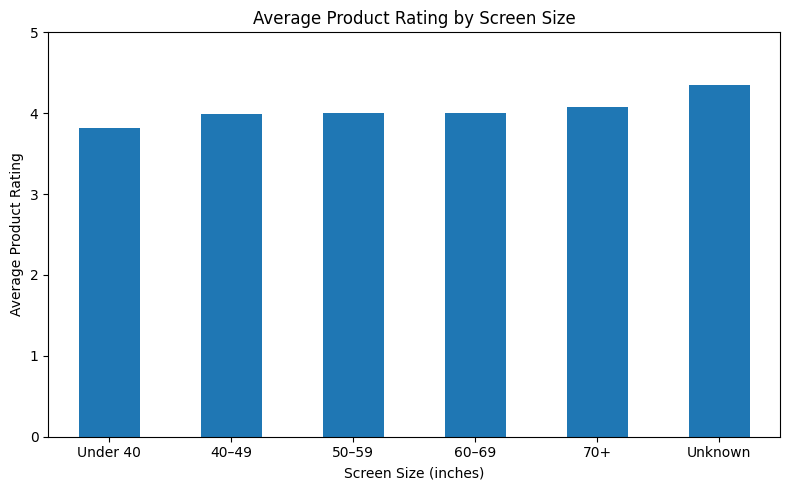

In [90]:
plt.figure(figsize=(8, 5))

size_satisfaction["avg_rating"].plot(
    kind="bar"
)

plt.title(
    "Average Product Rating by Screen Size"
)

plt.xlabel(
    "Screen Size (inches)"
)

plt.ylabel(
    "Average Product Rating"
)

plt.ylim(0, 5)

plt.xticks(rotation=0)

# Rating by Screen Size
plt.savefig(
    f"{FIGURE_DIR}/03_rating_by_screen_size.png",
    dpi=300,
    bbox_inches="tight"
)


plt.tight_layout()
plt.show()


In [61]:
resolution_satisfaction = (
    product_analysis
    .dropna(
        subset=["product_avg_rating"]
    )
    .groupby("resolution")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean"),
        median_rating=("product_avg_rating", "median"),
        avg_reviews=("review_count", "mean")
    )
    .sort_values(
        "avg_rating",
        ascending=False
    )
)

display(
    resolution_satisfaction.round(2)
)

,products,avg_rating,median_rating,avg_reviews
resolution,,,,
4K,911,4.04,4.12,80.20
1080p,84,3.92,3.91,168.74
720p,45,3.92,4.02,370.64
8K,25,3.70,3.67,20.32
Unknown,31,3.62,3.62,218.35


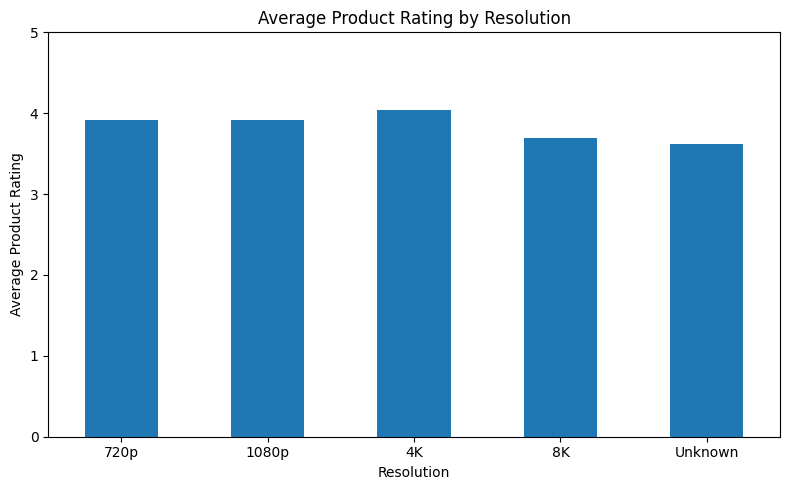

In [91]:
resolution_order = [
    "720p",
    "1080p",
    "4K",
    "8K",
    "Unknown"
]

resolution_plot = (
    resolution_satisfaction
    .reindex(resolution_order)
    .dropna()
)

plt.figure(figsize=(8, 5))

resolution_plot["avg_rating"].plot(
    kind="bar"
)

plt.title(
    "Average Product Rating by Resolution"
)

plt.xlabel(
    "Resolution"
)

plt.ylabel(
    "Average Product Rating"
)

plt.ylim(0, 5)

plt.xticks(rotation=0)

# Rating by Resolution
plt.savefig(
    f"{FIGURE_DIR}/03_rating_by_resolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()


In [63]:
display_satisfaction = (
    product_analysis
    .dropna(
        subset=["product_avg_rating"]
    )
    .groupby("display_type")
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean"),
        median_rating=("product_avg_rating", "median"),
        avg_reviews=("review_count", "mean")
    )
    .sort_values(
        "avg_rating",
        ascending=False
    )
)

display(
    display_satisfaction.round(2)
)

,products,avg_rating,median_rating,avg_reviews
display_type,,,,
OLED,159,4.29,4.50,43.77
NanoCell,24,4.26,4.37,34.46
Mini-LED,25,4.01,3.94,101.48
LED/LCD,485,3.98,4.01,123.39
QLED,227,3.95,4.00,59.38
Unknown,176,3.86,4.00,156.49


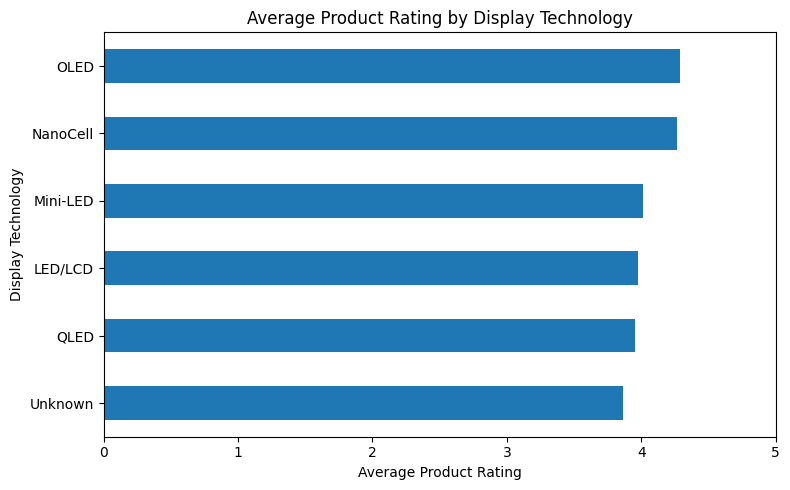

In [92]:
plt.figure(figsize=(8, 5))

display_satisfaction[
    "avg_rating"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Average Product Rating by Display Technology"
)

plt.xlabel(
    "Average Product Rating"
)

plt.ylabel(
    "Display Technology"
)

plt.xlim(0, 5)

# Rating by Display Technology
plt.savefig(
    f"{FIGURE_DIR}/03_rating_by_display_technology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

If basic product specifications do not fully explain satisfaction, what aspects of the ownership experience do?

In [65]:
display_brand_tech = (
    product_analysis[
        product_analysis["display_type"]
        != "Unknown"
    ]
    .pivot_table(
        index="brand",
        columns="display_type",
        values="product_avg_rating",
        aggfunc=["mean", "count"]
    )
)

display(
    display_brand_tech.round(2)
)

mean                                 count                    \
display_type LED/LCD Mini-LED NanoCell  OLED  QLED LED/LCD Mini-LED NanoCell   
brand                                                                          
Hisense         3.59     4.31      NaN   NaN  3.79    35.0      3.0      NaN   
LG              4.05     3.58     4.26  4.24  3.90   128.0      2.0     24.0   
Samsung         3.96     3.75      NaN  4.14  3.95   143.0      8.0      NaN   
Sony            4.06     4.67      NaN  4.38   NaN   128.0      5.0      NaN   
TCL             3.90     3.85      NaN   NaN  4.11    51.0      7.0      NaN   

                           
display_type  OLED   QLED  
brand                      
Hisense        NaN   14.0  
LG            89.0    1.0  
Samsung       11.0  198.0  
Sony          59.0    NaN  
TCL            NaN   14.0

In [66]:
brand_display_summary = (
    product_analysis[
        (product_analysis["display_type"] != "Unknown")
        &
        (product_analysis["product_avg_rating"].notna())
    ]
    .groupby(
        ["brand", "display_type"]
    )
    .agg(
        products=("parent_asin", "count"),
        avg_rating=("product_avg_rating", "mean")
    )
    .reset_index()
)

display(
    brand_display_summary
    .sort_values(
        ["brand", "products"],
        ascending=[True, False]
    )
    .round(2)
)

,brand,display_type,products,avg_rating
0,Hisense,LED/LCD,35,3.59
2,Hisense,QLED,14,3.79
1,Hisense,Mini-LED,3,4.31
3,LG,LED/LCD,128,4.05
6,LG,OLED,89,4.24
5,LG,NanoCell,24,4.26
4,LG,Mini-LED,2,3.58
7,LG,QLED,1,3.90
11,Samsung,QLED,198,3.95
8,Samsung,LED/LCD,143,3.96


Basic hardware specifications show only modest differences in overall customer satisfaction. OLED products receive relatively higher ratings, including within several brands, but screen size and resolution show limited differentiation. This suggests that customer satisfaction may depend less on specifications alone and more on the broader ownership experience captured in review text.

In [67]:
products_final = products.drop(
    columns=["title_display_type"],
    errors="ignore"
).copy()

products_final.to_parquet(
    "tv_products_analysis.parquet",
    index=False
)

reviews.to_parquet(
    "tv_reviews_analysis.parquet",
    index=False
)

print(
    "Products saved:",
    products_final.shape
)

print(
    "Reviews saved:",
    reviews.shape
)

Products saved: (1097, 20)
Reviews saved: (111191, 14)


In [68]:
product_analysis.to_parquet(
    "tv_product_performance.parquet",
    index=False
)

print(
    "Product performance saved:",
    product_analysis.shape
)

Product performance saved: (1097, 24)
